# Machine Learning Final Project : Ingredient Classification
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [1]:
%reset -f

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import operator
import gc
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input

### Load Cleaned Dataset

In [3]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

# Select all one-hot ingredient columns as targets
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
print(f'Ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Prepare input features (exclude ingredient one-hot columns)
exclude_cols = set(ingredient_oh_cols)
feature_cols = [col for col in food_data.columns if col not in exclude_cols]

Ingredient one-hot columns: ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt', 'ingredient_oh_natural', 'ingredient_oh_dextrose'] ... total: 1000


## Step 1: Train/Test Split

In [4]:
# Batch generator for memory-efficient training
def batch_generator(data, feature_cols, target_cols, window_size=3, batch_size=128):
    num_rows = len(data)
    while True:
        for start in range(window_size, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            X_batch = []
            y_batch = []
            for i in range(start, end):
                X_window = data.iloc[i-window_size:i][feature_cols].values
                y_row = data.iloc[i][target_cols].values
                X_batch.append(X_window)
                y_batch.append(y_row)
            yield np.array(X_batch), np.array(y_batch)

In [5]:
# Set window size and batch size
window_size = 3
batch_size = 128

# Calculate split index for train/test
num_rows = len(food_data)
split_idx = int((num_rows - window_size) * 0.8)
print(f'[Split] Total rows: {num_rows}, Train rows: {split_idx + window_size}, Test rows: {num_rows - split_idx}')

# Define train and test generators
train_gen = batch_generator(
    food_data.iloc[:split_idx + window_size],
    feature_cols,
    ingredient_oh_cols,
    window_size=window_size,
    batch_size=batch_size
)
test_gen = batch_generator(
    food_data.iloc[split_idx:],
    feature_cols,
    ingredient_oh_cols,
    window_size=window_size,
    batch_size=batch_size
)

# Calculate steps per epoch
train_steps = (split_idx) // batch_size
test_steps = (num_rows - window_size - split_idx) // batch_size
print(f'[Steps] Train steps per epoch: {train_steps}, Test steps: {test_steps}')

[Split] Total rows: 1977398, Train rows: 1581919, Test rows: 395482
[Steps] Train steps per epoch: 12358, Test steps: 3089


## Step 2: Build the Model

In [6]:
# Build the LSTM model for multi-label ingredient prediction
print(f'[Model] Building LSTM model with input shape ({window_size}, {len(feature_cols)}) and output size {len(ingredient_oh_cols)}')
model = Sequential()
model.add(Input(shape=(window_size, len(feature_cols))))
model.add(LSTM(units=128, return_sequences=True))
model.add(Dropout(0.2))

# Second LSTM layer with dropout regularization
model.add(LSTM(units=128))
model.add(Dropout(0.2))

# Final dense output layer for all ingredient one-hot columns (sigmoid for multi-label)
model.add(Dense(len(ingredient_oh_cols), activation='sigmoid'))

[Model] Building LSTM model with input shape (3, 242) and output size 1000


In [7]:
# Compile the model with Adam optimizer and binary crossentropy loss function
print('[Model] Compiling model...')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

[Model] Compiling model...


## Step 3: Train the Model

In [ ]:
# Fit the model using the batch generator
print(f'[Training] Starting model.fit for 10 epochs, batch size {batch_size}, train steps {train_steps}, validation steps {test_steps}')
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=3,
    validation_data=test_gen,
    validation_steps=test_steps
)

[Training] Starting model.fit for 10 epochs, batch size 128, train steps 12358, validation steps 3089
Epoch 1/10
Epoch 1/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2104s 170ms/step - accuracy: 0.4780 - loss: 0.0372 - val_accuracy: 0.5426 - val_loss: 0.0380
Epoch 2/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2104s 170ms/step - accuracy: 0.4780 - loss: 0.0372 - val_accuracy: 0.5426 - val_loss: 0.0380
Epoch 2/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2043s 165ms/step - accuracy: 0.4900 - loss: 0.0364 - val_accuracy: 0.5426 - val_loss: 0.0380
Epoch 3/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2043s 165ms/step - accuracy: 0.4900 - loss: 0.0364 - val_accuracy: 0.5426 - val_loss: 0.0380
Epoch 3/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1983s 160ms/step - accuracy: 0.4919 - loss: 0.0363 - val_accuracy: 0.5425 - val_loss: 0.0380
Epoch 4/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1983s 160ms/step - accuracy: 0.4919 - loss: 0.0363 - val_accuracy: 0.5425 - val_loss: 0.0380
Epoch 4/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2055s 166ms/step - ac

In [9]:
# Collect predictions and true values from test generator for accuracy calculation
y_true = []
y_pred = []
for batch_num in range(test_steps):
    X_batch, y_batch = next(test_gen)
    preds = model.predict(X_batch)
    y_true.append(y_batch)
    y_pred.append(preds)
    gc.collect()
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

# Binarize predictions at threshold 0.5
y_pred_bin = (y_pred > 0.5).astype(np.uint8)

# Calculate accuracy for each ingredient
accuracies = (y_true == y_pred_bin).mean(axis=0)
for col, acc in zip(ingredient_oh_cols, accuracies):
    print(f'Accuracy for {col}: {acc:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━

## Step 4: Evaluate the Model

Ingredient Prediction Accuracy Summary:
Mean Accuracy: 0.9919
Median Accuracy: 0.9975
Min Accuracy: 0.5379
Max Accuracy: 0.9998


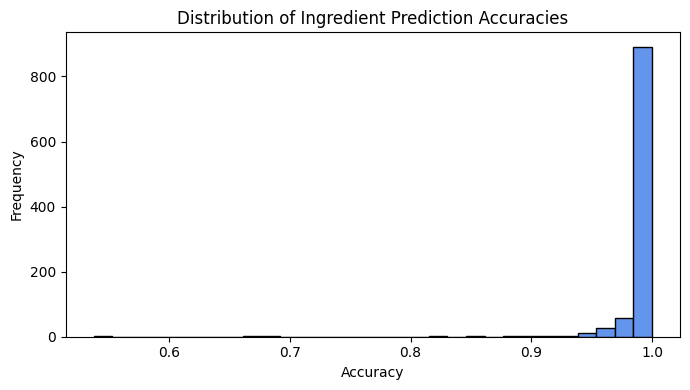

In [10]:
# Print summary statistics for ingredient prediction accuracies
print('Ingredient Prediction Accuracy Summary:')
print(f'Mean Accuracy: {np.mean(accuracies):.4f}')
print(f'Median Accuracy: {np.median(accuracies):.4f}')
print(f'Min Accuracy: {np.min(accuracies):.4f}')
print(f'Max Accuracy: {np.max(accuracies):.4f}')

# Plot accuracy distribution (histogram)
plt.figure(figsize=(7,4))
plt.hist(accuracies, bins=30, color='cornflowerblue', edgecolor='black')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Distribution of Ingredient Prediction Accuracies')
plt.tight_layout()
plt.show()

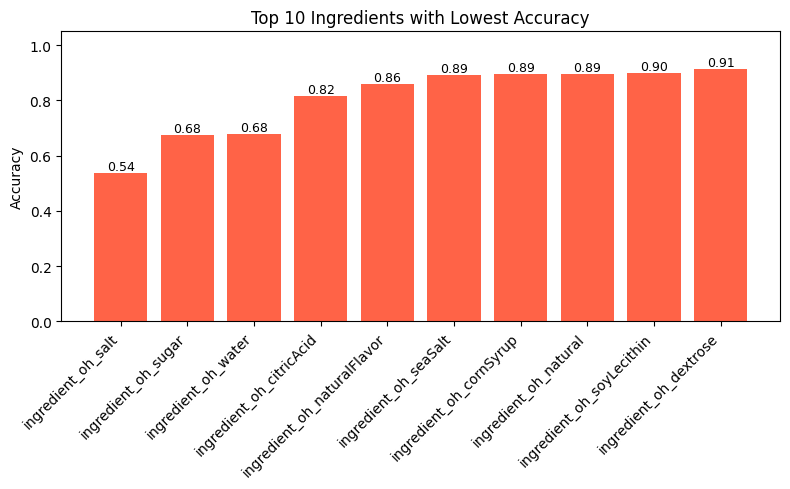

In [11]:
# Plot top 10 ingredients with lowest accuracy
top_n = 10
ingredient_acc_pairs = list(zip(ingredient_oh_cols, accuracies))
ingredient_acc_pairs.sort(key=operator.itemgetter(1))
bottom_ingredients, bottom_accs = zip(*ingredient_acc_pairs[:top_n])
plt.figure(figsize=(8, 5))
bars = plt.bar(bottom_ingredients, bottom_accs, color='tomato')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title(f'Top {top_n} Ingredients with Lowest Accuracy')
plt.tight_layout()
plt.ylim(0, max(bottom_accs) * 1.15)
for bar, value in zip(bars, bottom_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom', fontsize=9)
plt.show()

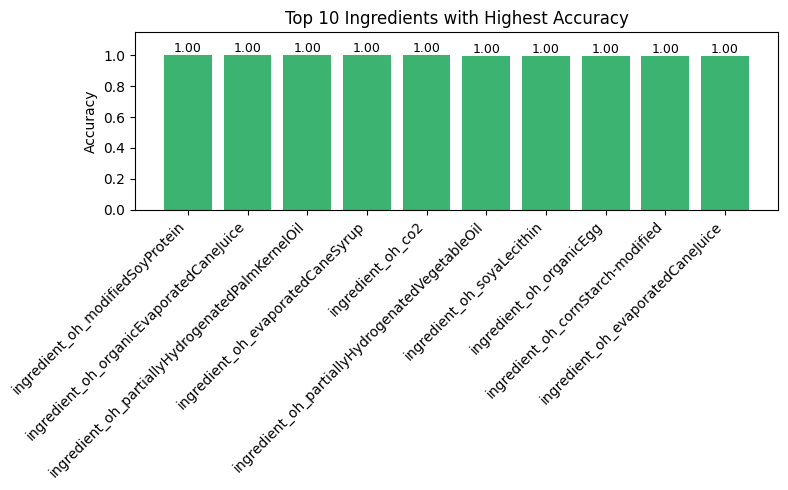

In [12]:
# Plot top 10 ingredients with highest accuracy
top_n = 10
ingredient_acc_pairs = list(zip(ingredient_oh_cols, accuracies))
ingredient_acc_pairs.sort(key=operator.itemgetter(1), reverse=True)
top_ingredients, top_accs = zip(*ingredient_acc_pairs[:top_n])
plt.figure(figsize=(8, 5))
bars = plt.bar(top_ingredients, top_accs, color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title(f'Top {top_n} Ingredients with Highest Accuracy')
plt.tight_layout()
plt.ylim(0, max(top_accs) * 1.15)
for bar, value in zip(bars, top_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom', fontsize=9)
plt.show()